In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, make_scorer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
import xgboost as xgb # xgb.__version__ '2.1.3'
from catboost import CatBoostRegressor
import optuna
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [3]:
data=pd.read_excel("../Data/BUS/Bus_FE_Processed.xlsx",engine="openpyxl")
original_data=data.copy()
# data=data.drop(columns=['COST_INDEX','Unnamed: 0','區議會分區（中文名稱)','Unnamed: 0.1'])
data=data.drop(columns=['區議會分區（中文名稱)','COST_INDEX'])

In [4]:
data.rename(columns={
    '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2': 'median_monthly_income_by_gender_excluding_unpaid_family_workers',
    '按房屋類型劃分的有人居住的屋宇單位數目.3': 'occupied_housing_units_by_type',
    '按房屋類型劃分的家庭住戶數目.3': 'households_by_housing_type',
    '家庭住戶每月按揭供款及借貸還款與收入比率中位數': 'median_mortgage_repayment_to_income_ratio',
    '按上課地點劃分的於香港院校就讀全日制課程的人口.2': 'full_time_students_by_institution_location',
    '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2': 'households_by_number_of_rooms',
    '家庭住戶平均人數': 'average_household_size',
    '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2': 'households_with_mortgage_by_repayment_amount',
    '按房屋類型劃分的人口.3': 'population_by_housing_type',
    '按行業(9)劃分的工作人口.3': 'working_population_by_industry_9_categories',
    '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目': 'households_by_monthly_rent',
    '按行業(9)劃分的工作人口.5': 'working_population_by_industry_5_categories',
    '按工作地點劃分的工作人口.2': 'working_population_by_work_location',
    '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_unpaid_family_workers',
    '按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_foreign_domestic_workers',
    '按住戶人數劃分的家庭住戶數目': 'households_by_size',
    '按住戶結構劃分的家庭住戶數目.6': 'households_by_structure'
}, inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 43 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   Unnamed: 0                                                               4513 non-null   int64  
 1   PRICE                                                                    4513 non-null   float64
 2   SPECIAL_TYPE                                                             4513 non-null   int64  
 3   JOURNEY_TIME                                                             4513 non-null   int64  
 4   DISTANCE                                                                 4513 non-null   int64  
 5   median_monthly_income_by_gender_excluding_unpaid_family_workers          4513 non-null   int64  
 6   occupied_housing_units_by_type                                          

In [6]:
TARGET='PRICE'

In [7]:
def clean_non_ascii(text):
    if isinstance(text, str):
        return ''.join([char if ord(char) < 128 else '' for char in text])
    return text

data = data.map(clean_non_ascii)

In [8]:
train, test = train_test_split(data, test_size=0.3, random_state=42)

In [9]:
X = train.drop([TARGET], axis=1)
y = train[TARGET]
X_test = test.drop([TARGET], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

In [10]:
import lightgbm as lgb
import time
n_fold = 10

import matplotlib.pyplot as plt
folds = KFold(n_splits=n_fold, shuffle=True, random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import shap

def train_model(X, X_test, y, params=None, folds=folds, model_type='lgb', plot_feature_importance=False, model=None, importance_threshold=0):

    oof = np.zeros(X.shape[0])
    prediction = np.zeros(X_test.shape[0])
    scores = []
    feature_importance = pd.DataFrame()
    # 初始化SHAP值存储
    all_shap_values = []
    all_X_valid = []
    # Step 1: Train and record feature importances
    for fold_n, (train_index, valid_index) in enumerate(folds.split(X)):
        print('Fold', fold_n, 'started at', time.ctime())
        if model_type == 'sklearn':
            X_train, X_valid = X[train_index], X[valid_index]
        else:
            X_train, X_valid = X.values[train_index], X.values[valid_index]
        # y_train, y_valid = y[train_index], y[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index] 

        if model_type == 'lgb':
            model = lgb.LGBMRegressor(**params, n_estimators=20000, nthread=4, n_jobs=-1)
            model.fit(X_train, y_train, 
                      eval_set=[(X_train, y_train), (X_valid, y_valid)], eval_metric='rmse')
            
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test, num_iteration=model.best_iteration_)
            # 计算当前折的SHAP值
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_valid)
            
            # 保存SHAP值和验证集数据
            all_shap_values.append(shap_values)
            all_X_valid.append(X_valid)          
        
        elif model_type == 'xgb':
            train_data = xgb.DMatrix(data=X_train, label=y_train)
            valid_data = xgb.DMatrix(data=X_valid, label=y_valid)

            watchlist = [(train_data, 'train'), (valid_data, 'valid_data')]
            model = xgb.train(dtrain=train_data, num_boost_round=20000, evals=watchlist, early_stopping_rounds=200, verbose_eval=500, params=params)
            y_pred_valid = model.predict(xgb.DMatrix(X_valid), iteration_range=(0, model.best_iteration + 1))
            y_pred = model.predict(xgb.DMatrix(X_test.values),  iteration_range=(0, model.best_iteration + 1))
        
        elif model_type == 'sklearn':
            model = model
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid).reshape(-1,)
            score = mean_squared_error(y_valid, y_pred_valid)
            
            y_pred = model.predict(X_test)
        
        elif model_type == 'cat':
            model = CatBoostRegressor(iterations=20000,  eval_metric='RMSE', **params)
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=[], use_best_model=True, verbose=False)

            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        elif model_type == 'randomforest':
            model = RandomForestRegressor(**params, n_jobs=-1, random_state=42)
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        oof[valid_index] = y_pred_valid.reshape(-1,)
        mse = mean_squared_error(y_valid, y_pred_valid) ** 0.5
        print("mse----------->", mse)
        scores.append(mse)
        
        prediction += y_pred

        if model_type == 'lgb':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)
        elif model_type =='randomforest':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    prediction /= folds.n_splits
    
    print('CV mean score: {0:.4f}, std: {1:.4f}.'.format(np.mean(scores), np.std(scores)))

    if model_type == 'lgb':
        feature_importance["importance"] /= folds.n_splits
            # 合并所有折的SHAP值
        combined_shap = np.vstack(all_shap_values)  # 形状: (n_samples_total, n_features)
        combined_X_valid = np.vstack(all_X_valid)   # 形状: (n_samples_total, n_features)
        
        # 绘制SHAP汇总图（所有折的综合结果）
        # 截断过长的字段名（保留前10个字符 + '...'）
        shortened_names = [name[:30] + '...' if len(name) > 10 else name for name in X.columns]
        # shortened_names = [name.replace('_', '_\n') if len(name) > 15 else name for name in X.columns]
        plt.figure(figsize=(10, 20))
        shap.summary_plot(combined_shap, combined_X_valid, feature_names=shortened_names, show=False)
        plt.title(f'SHAP value for {model_type}-BUS', fontsize=14)  # 自定义标题
        # plt.tight_layout()
        plt.show()
        # Optional: Plot feature importance if specified
        if plot_feature_importance:
            cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
                by="importance", ascending=False)[:50].index
            best_features = feature_importance.loc[feature_importance.feature.isin(cols)]

            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('LGB Features (avg over folds)')
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance            
    elif model_type =='randomforest':
        feature_importance["importance"] /= folds.n_splits
        if plot_feature_importance:
            #plot the frature importance 
            cols = feature_importance.groupby("feature")["importance"].mean().sort_values(ascending=False)[:50].index
            best_features = feature_importance[feature_importance["feature"].isin(cols)]

            # 绘制条形图
            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('Random Forest Feature Importance (Avg over Folds)')
            plt.tight_layout()
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance

    else:
        return oof, prediction


In [11]:
X_train_np = X_train.values
y_train_np = y_train.values
X_valid_np = X_valid.values
y_valid_np = y_valid.values
X_train_np = np.nan_to_num(X_train_np, nan=0)
X_valid_np = np.nan_to_num(X_valid_np, nan=0)

from xgboost.callback import EarlyStopping
from lightgbm import early_stopping, log_evaluation

def objective(trial, model_type):
    if model_type == 'xgboost':
        param = {
            'objective': 'reg:squarederror',
            'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'eval_metric':'rmse',
            'early_stopping_rounds':50,
            'n_estimators': 1000
        }
        model = xgb.XGBRegressor(**param, n_jobs=-1, random_state=42)

    elif model_type == 'lightgbm':
        param = {
            'objective': 'regression',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', -1, 10),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
            'n_estimators': 1000,
            'verbosity': -1  # Suppress warnings
        }
        model = lgb.LGBMRegressor(**param, n_jobs=-1, random_state=42)

        callbacks = [early_stopping(stopping_rounds=50, verbose=False)]

    elif model_type == 'catboost':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'od_wait': trial.suggest_int('od_wait', 10, 200),
            'iterations': 1000,
            'eval_metric': 'RMSE',  # Specify evaluation metric here
            'random_state': 42,
            'silent': True  # Suppress output
        }
        model = CatBoostRegressor(**param)
    elif model_type == 'randomforest':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**param)


    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Train the model
    if model_type == 'lightgbm':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    elif model_type == 'catboost':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)]
        )
    elif model_type=='randomforest':
        model.fit(
            X_train_np, y_train_np
        )
    else:
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            #early_stopping_rounds=50,  
            verbose=False
        )

    # Predict and calculate RMSE
    y_pred = model.predict(X_valid_np)
    rmse = np.sqrt(mean_squared_error(y_valid_np, y_pred))
    return rmse

def optimize_model(model_type, n_trials=10):
    def wrapped_objective(trial):
        return objective(trial, model_type)

    study = optuna.create_study(direction='minimize')
    study.optimize(wrapped_objective, n_trials=n_trials)
    print(f"Best parameters for {model_type}:")
    print(study.best_trial.params)
    print(f"Best RMSE for {model_type}: {study.best_trial.value}")
    return study

In [12]:
lgb_study = optimize_model('lightgbm')

[I 2025-04-29 20:00:51,326] A new study created in memory with name: no-name-2568b9bf-b7e8-4f92-8644-2d7829dfef90
[I 2025-04-29 20:00:52,292] Trial 0 finished with value: 1.1630586146518864 and parameters: {'learning_rate': 0.05868680793577689, 'max_depth': 0, 'num_leaves': 97, 'feature_fraction': 0.7727209152433168, 'bagging_fraction': 0.6301276401154052, 'lambda_l1': 0.035770572741331504, 'lambda_l2': 0.0009056034697385647, 'min_child_samples': 5}. Best is trial 0 with value: 1.1630586146518864.
[I 2025-04-29 20:00:52,728] Trial 1 finished with value: 1.2349197589144096 and parameters: {'learning_rate': 0.06469774148703208, 'max_depth': 3, 'num_leaves': 202, 'feature_fraction': 0.7345821113627128, 'bagging_fraction': 0.6851486692644224, 'lambda_l1': 0.434509938873174, 'lambda_l2': 1.0579288917853767e-06, 'min_child_samples': 8}. Best is trial 0 with value: 1.1630586146518864.
[I 2025-04-29 20:00:53,093] Trial 2 finished with value: 1.376231328054972 and parameters: {'learning_rate': 

Best parameters for lightgbm:
{'learning_rate': 0.05868680793577689, 'max_depth': 0, 'num_leaves': 97, 'feature_fraction': 0.7727209152433168, 'bagging_fraction': 0.6301276401154052, 'lambda_l1': 0.035770572741331504, 'lambda_l2': 0.0009056034697385647, 'min_child_samples': 5}
Best RMSE for lightgbm: 1.1630586146518864


Fold 0 started at Tue Apr 29 20:00:55 2025


mse-----------> 1.3139179735300022
Fold 1 started at Tue Apr 29 20:01:14 2025
mse-----------> 1.260301287667709
Fold 2 started at Tue Apr 29 20:01:33 2025
mse-----------> 1.2407163566798447
Fold 3 started at Tue Apr 29 20:01:56 2025
mse-----------> 1.1950508342899246
Fold 4 started at Tue Apr 29 20:02:15 2025
mse-----------> 1.23835072106537
Fold 5 started at Tue Apr 29 20:02:31 2025
mse-----------> 1.296755038513504
Fold 6 started at Tue Apr 29 20:02:49 2025
mse-----------> 1.3451099061504015
Fold 7 started at Tue Apr 29 20:03:07 2025
mse-----------> 1.3925567868692952
Fold 8 started at Tue Apr 29 20:03:27 2025
mse-----------> 1.0434072218325312
Fold 9 started at Tue Apr 29 20:03:46 2025
mse-----------> 1.2090660050962914
CV mean score: 1.2535, std: 0.0912.


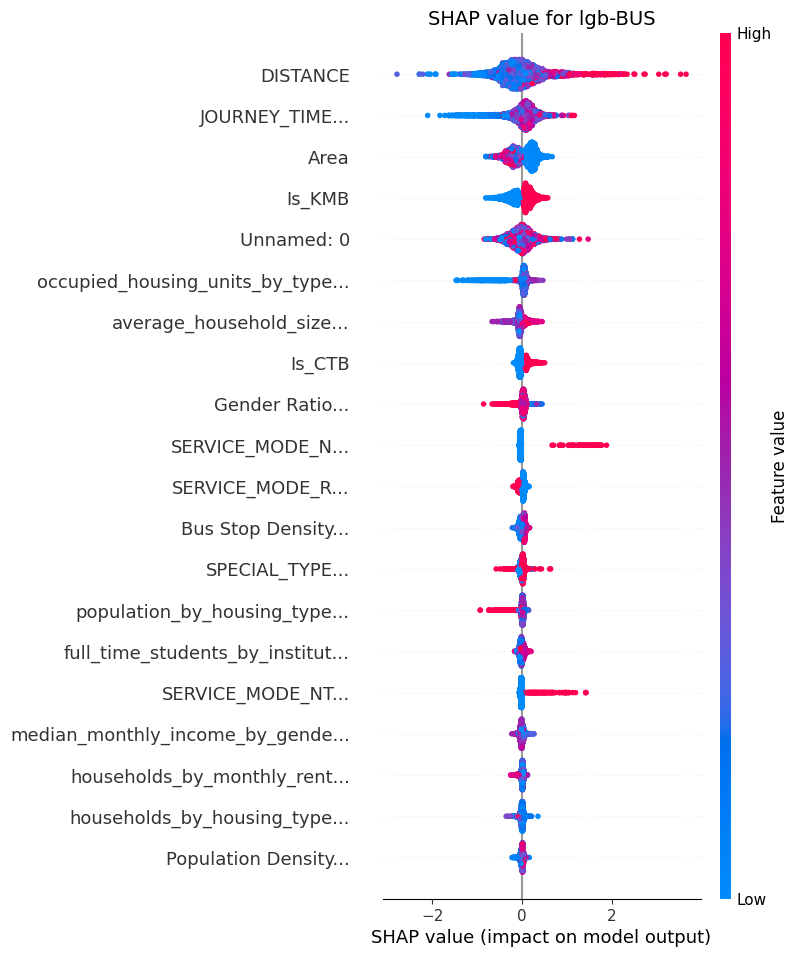

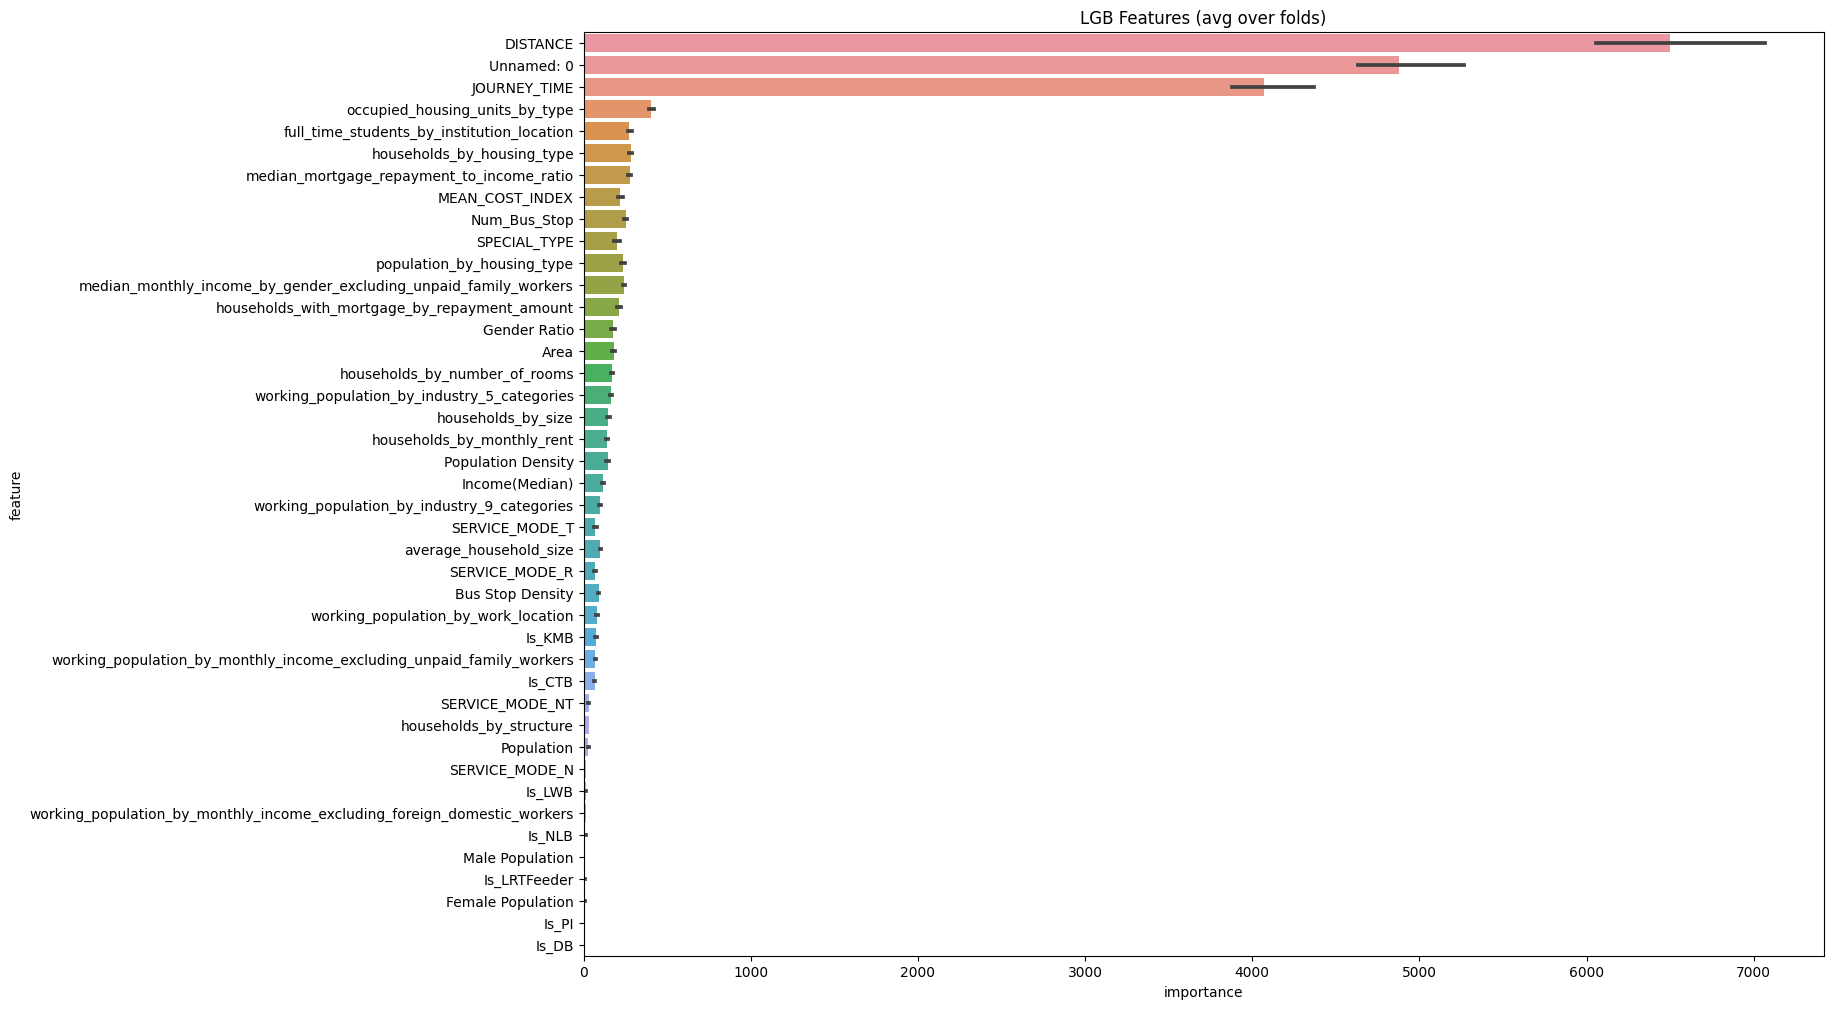

In [13]:
oof_lgb, prediction_lgb, _ = train_model(X, X_test, y, params=lgb_study.best_params, model_type='lgb', plot_feature_importance=True)


In [14]:
rf_study = optimize_model('randomforest', n_trials=50)

[I 2025-04-29 20:04:08,262] A new study created in memory with name: no-name-1a91104c-a5d4-42f9-9341-7ecb03d82e59
[I 2025-04-29 20:04:09,634] Trial 0 finished with value: 1.4112220099353114 and parameters: {'n_estimators': 921, 'max_depth': 4, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 1.4112220099353114.
[I 2025-04-29 20:04:10,692] Trial 1 finished with value: 1.2846449461336835 and parameters: {'n_estimators': 613, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 1.2846449461336835.
[I 2025-04-29 20:04:11,664] Trial 2 finished with value: 1.3118820970440246 and parameters: {'n_estimators': 537, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 1.2846449461336835.
[I 2025-04-29 20:04:12,324] Trial 3 finished with value: 1.375763623047281 and parameters: {'n_estimators': 425, 'max_depth': 6, 'min

KeyboardInterrupt: 

In [ ]:
rf_study.best_params

{'n_estimators': 599,
 'max_depth': 22,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': None}

Fold 0 started at Sun Apr 13 13:58:18 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.1926245964447661
Fold 1 started at Sun Apr 13 13:58:20 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.162578739979329
Fold 2 started at Sun Apr 13 13:58:22 2025


...

mse-----------> 1.2048179327922466
Fold 8 started at Sun Apr 13 13:58:33 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.0296004057135417
Fold 9 started at Sun Apr 13 13:58:35 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.1743815026067066
CV mean score: 1.1869, std: 0.0675.


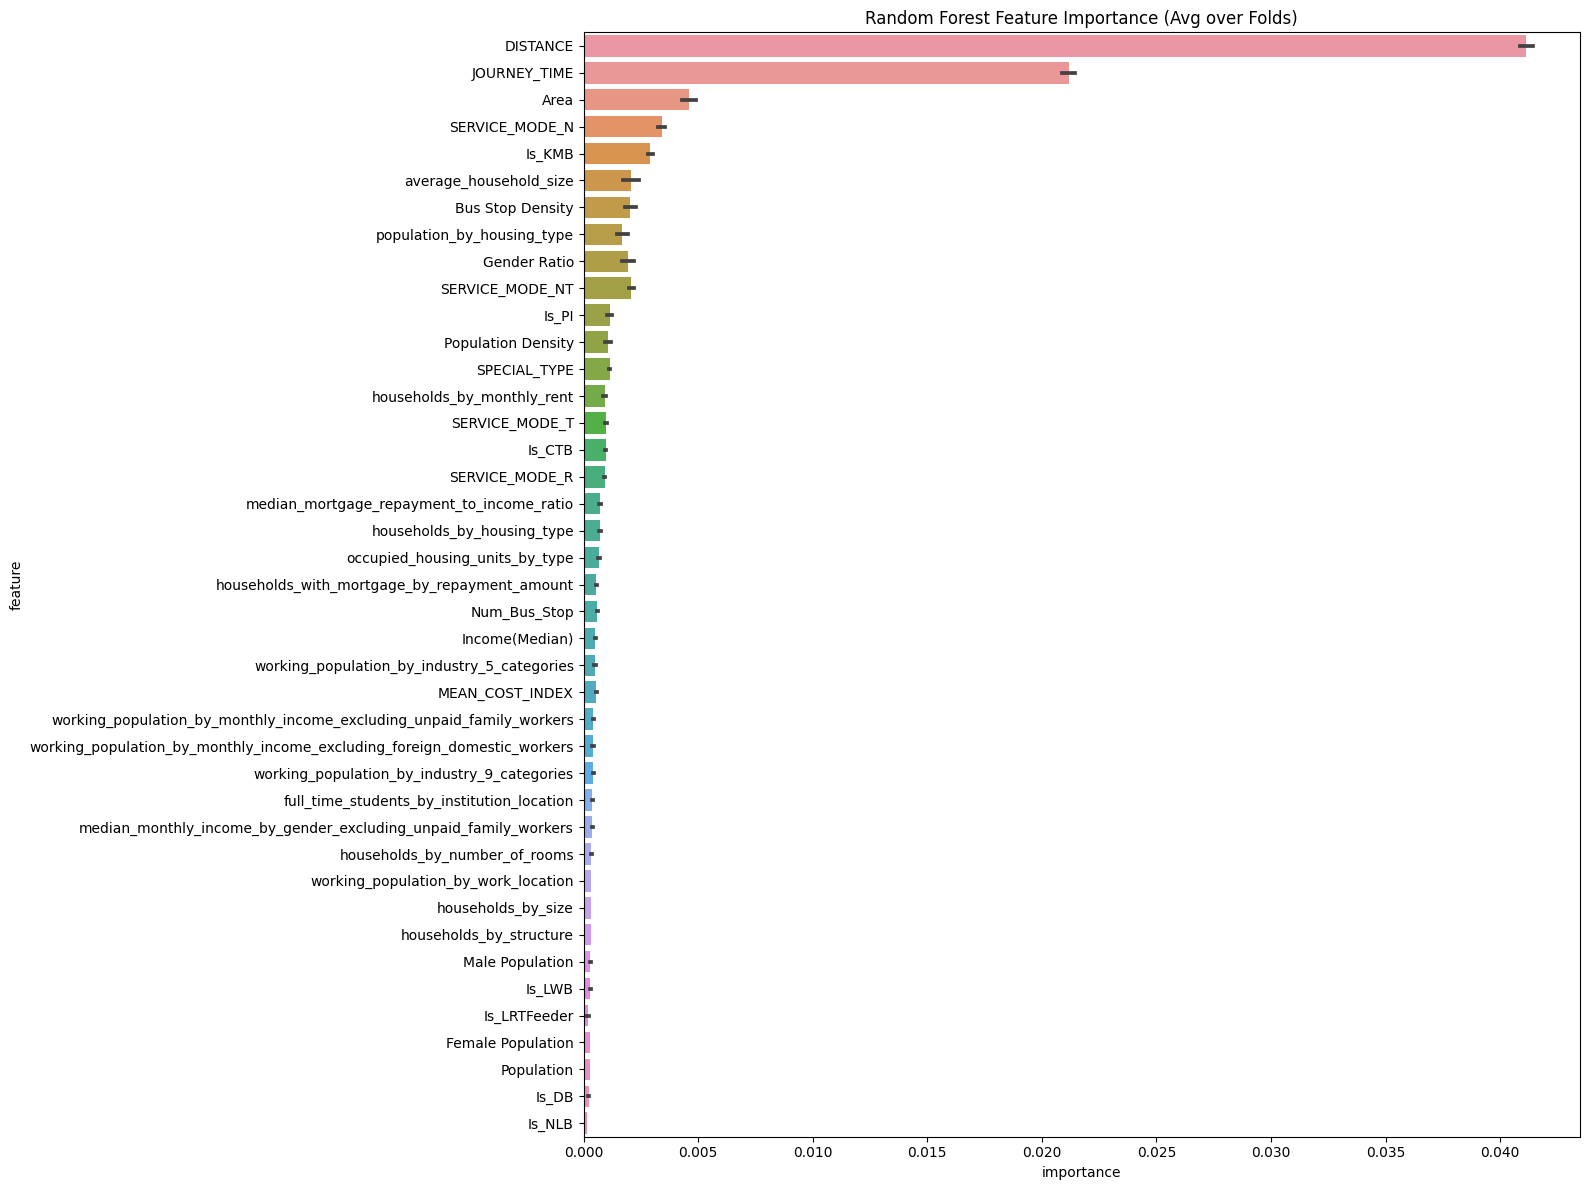

In [ ]:
oof_rf, prediction_rf,feature_importance= train_model(X, X_test, y, params=rf_study.best_params, model_type='randomforest', plot_feature_importance=True)


In [ ]:
catboost_study = optimize_model('catboost')

[I 2025-04-13 13:58:38,522] A new study created in memory with name: no-name-248b7745-64ca-4cf4-b723-885510eeaf2c
[I 2025-04-13 13:58:42,054] Trial 0 finished with value: 1.2799319306361945 and parameters: {'learning_rate': 0.22609379679317274, 'depth': 9, 'l2_leaf_reg': 8.302107338733542, 'bagging_temperature': 9.52910761279828, 'colsample_bylevel': 0.8843822516421689, 'od_wait': 124}. Best is trial 0 with value: 1.2799319306361945.
[I 2025-04-13 13:58:44,059] Trial 1 finished with value: 1.2710582067015725 and parameters: {'learning_rate': 0.06604291985618589, 'depth': 7, 'l2_leaf_reg': 0.003982251157433093, 'bagging_temperature': 6.026683115244564, 'colsample_bylevel': 0.8125874995319293, 'od_wait': 47}. Best is trial 1 with value: 1.2710582067015725.
[I 2025-04-13 13:58:45,154] Trial 2 finished with value: 1.2597814532557627 and parameters: {'learning_rate': 0.06756379053923504, 'depth': 5, 'l2_leaf_reg': 0.5405294257378374, 'bagging_temperature': 7.149994969124824, 'colsample_byle

Best parameters for catboost:
{'learning_rate': 0.14178218908415763, 'depth': 6, 'l2_leaf_reg': 6.783897206850972e-06, 'bagging_temperature': 0.9123254656111723, 'colsample_bylevel': 0.7095269031003832, 'od_wait': 191}
Best RMSE for catboost: 1.2340180370599358


In [ ]:
catboost_study.best_params

{'learning_rate': 0.14178218908415763,
 'depth': 6,
 'l2_leaf_reg': 6.783897206850972e-06,
 'bagging_temperature': 0.9123254656111723,
 'colsample_bylevel': 0.7095269031003832,
 'od_wait': 191}

In [ ]:

oof_cat, prediction_cat = train_model(X, X_test, y, params=catboost_study.best_params, model_type='cat')


Fold 0 started at Sun Apr 13 13:59:02 2025
mse-----------> 1.228326341092777
Fold 1 started at Sun Apr 13 13:59:03 2025
mse-----------> 1.202872781325181
Fold 2 started at Sun Apr 13 13:59:06 2025
mse-----------> 1.2146868520591345
Fold 3 started at Sun Apr 13 13:59:08 2025
mse-----------> 1.1626201156148774
Fold 4 started at Sun Apr 13 13:59:11 2025
mse-----------> 1.1756828701893858
Fold 5 started at Sun Apr 13 13:59:12 2025
mse-----------> 1.2744315546744192
Fold 6 started at Sun Apr 13 13:59:13 2025
mse-----------> 1.2461419278653054
Fold 7 started at Sun Apr 13 13:59:15 2025
mse-----------> 1.22861552157681
Fold 8 started at Sun Apr 13 13:59:17 2025
mse-----------> 1.0266554878038228
Fold 9 started at Sun Apr 13 13:59:19 2025
mse-----------> 1.2266438976007705
CV mean score: 1.1987, std: 0.0650.


In [ ]:
train_stack = np.vstack([oof_lgb, oof_cat,oof_rf]).transpose()
train_stack = pd.DataFrame(train_stack, columns=['lgb', 'cat','rf'])
test_stack = np.vstack([prediction_lgb, prediction_cat,prediction_rf]).transpose()
test_stack = pd.DataFrame(test_stack, columns=['lgb', 'cat','rf'])
model = linear_model.RidgeCV(alphas=(0.01, 0.1, 1.0, 10.0, 100.0), scoring='neg_mean_squared_error', cv=folds)
oof_rcv_stack, prediction_rcv_stack = train_model(train_stack.values, test_stack.values, y, params=None, model_type='sklearn', model=model)

Fold 0 started at Sun Apr 13 13:59:22 2025
mse-----------> 1.1788678039793625
Fold 1 started at Sun Apr 13 13:59:22 2025
mse-----------> 1.165395605573847
Fold 2 started at Sun Apr 13 13:59:22 2025
mse-----------> 1.1881301792929584
Fold 3 started at Sun Apr 13 13:59:22 2025
mse-----------> 1.146362410463006
Fold 4 started at Sun Apr 13 13:59:23 2025
mse-----------> 1.1261643388482911
Fold 5 started at Sun Apr 13 13:59:23 2025
mse-----------> 1.2325802574768743
Fold 6 started at Sun Apr 13 13:59:23 2025
mse-----------> 1.2634064841067747
Fold 7 started at Sun Apr 13 13:59:23 2025
mse-----------> 1.1906722050889438
Fold 8 started at Sun Apr 13 13:59:23 2025
mse-----------> 0.9944660317501156
Fold 9 started at Sun Apr 13 13:59:23 2025
mse-----------> 1.181477286298612
CV mean score: 1.1668, std: 0.0684.


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lgb_rmse = np.sqrt(mean_squared_error(test[TARGET], prediction_lgb))
rf_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_rf))
cat_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_cat))
rcv_stack_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_rcv_stack))
lgb_r2=r2_score(test[TARGET], prediction_lgb)
rf_r2=r2_score(test[TARGET], prediction_rf)
cat_r2=r2_score(test[TARGET], prediction_cat)
rcv_stack_r2=r2_score(test[TARGET], prediction_rcv_stack)
print(prediction_lgb)


print("LGB_RMSE:", lgb_rmse)
print("RF_RMSE:", rf_rmse)
print("CAT_RMSE:", cat_rmse)
print("RCV_STACK_RMSE:", rcv_stack_rmse)
print('LGB_R2: ', lgb_r2)
print('RF_R2: ', rf_r2)
print('CAT_R2: ', cat_r2)
print('RCV_STACK_R2: ', rcv_stack_r2)

[7.26953513 5.29058529 6.84930474 ... 4.70352551 5.67774478 4.18312823]
LGB_RMSE: 1.1385710498832329
RF_RMSE: 1.1560820414760513
CAT_RMSE: 1.1432806775042446
RCV_STACK_RMSE: 1.1271623912740123
LGB_R2:  0.5314386384637
RF_R2:  0.5169150485988814
CAT_R2:  0.527554272053615
RCV_STACK_R2:  0.5407817083711579


In [ ]:
import pandas as pd
import numpy as np
outlier=test.copy()

outlier['residuals'] = test[TARGET] - prediction_rcv_stack

In [ ]:
from scipy.stats import skew, kurtosis
outlier['residuals_lgb'] = test[TARGET] - prediction_lgb
outlier['residuals_rf'] = test[TARGET] - prediction_rf
outlier['residuals_cat'] = test[TARGET] - prediction_cat
outlier['residuals_rcv_stack'] = test[TARGET] - prediction_rcv_stack

# Function to calculate residual statistics
def get_residual_stats(series):
    stats = {
        'Mean': np.mean(series),
        'Std Dev': np.std(series),
        'Skewness': skew(series),
        'Kurtosis': kurtosis(series),
        'Min': np.min(series),
        'Lower Quartile': np.quantile(series, 0.25),
        'Median': np.median(series),
        'Upper Quartile': np.quantile(series, 0.75),
        'Max': np.max(series),
        'IQR': np.quantile(series, 0.75) - np.quantile(series, 0.25)
    }
    return stats

# Create summary table
residual_stats = pd.DataFrame({
    'LGB': get_residual_stats(outlier['residuals_lgb']),
    'RF': get_residual_stats(outlier['residuals_rf']),
    'CAT': get_residual_stats(outlier['residuals_cat']),
    'RCV_STACK': get_residual_stats(outlier['residuals_rcv_stack'])

}).T

# Format the output
residual_stats = residual_stats[[
    'Mean', 'Std Dev', 'Skewness', 'Kurtosis',
    'Min', 'Lower Quartile', 'Median', 'Upper Quartile', 'Max', 'IQR'
]]

print("Residual Statistics Summary:")
print(residual_stats.round(4))

Residual Statistics Summary:
             Mean  Std Dev  Skewness  Kurtosis     Min  Lower Quartile  \
LGB       -0.0337   1.1381    0.0533    3.1527 -6.4032         -0.6410   
RF        -0.0507   1.1550   -0.0809    3.3314 -7.5634         -0.6567   
CAT       -0.0516   1.1421   -0.0232    3.4464 -6.9458         -0.6823   
RCV_STACK -0.0478   1.1261   -0.0405    3.3717 -7.0898         -0.6518   

           Median  Upper Quartile     Max     IQR  
LGB       -0.0503          0.5045  5.4162  1.1456  
RF        -0.0487          0.4876  4.9514  1.1443  
CAT       -0.0950          0.4797  4.8923  1.1621  
RCV_STACK -0.0793          0.4586  4.7662  1.1104  


In [ ]:
residual_stats

,Mean,Std Dev,Skewness,Kurtosis,Min,Lower Quartile,Median,Upper Quartile,Max,IQR
LGB,-0.033742,1.138071,0.053344,3.152654,-6.403205,-0.641039,-0.050287,0.504533,5.416202,1.145572
RF,-0.050721,1.154969,-0.080893,3.331396,-7.563366,-0.656731,-0.048714,0.487607,4.951395,1.144338
CAT,-0.051641,1.142114,-0.023180,3.446392,-6.945788,-0.682336,-0.095038,0.479744,4.892336,1.162080
RCV_STACK,-0.047764,1.126150,-0.040509,3.371676,-7.089825,-0.651784,-0.079280,0.458650,4.766207,1.110433


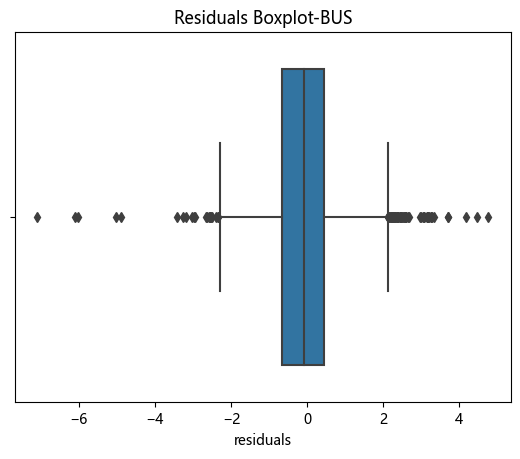

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制箱线图
sns.boxplot(x=outlier['residuals'])
plt.title('Residuals Boxplot-BUS')
plt.show()

# 计算异常阈值
Q1 = outlier['residuals'].quantile(0.25)
Q3 = outlier['residuals'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 标记异常点
boxplot_outliers = outlier[ (outlier['residuals'] > upper_bound)]

In [ ]:
mean = outlier['residuals'].mean()
std = outlier['residuals'].std()
lower_sigma = mean - 2 * std
upper_sigma = mean + 2 * std

# 标记异常点
sigma_outliers = outlier[ (outlier['residuals'] > upper_sigma)]

In [ ]:
boxplot_outliers_regions = original_data.loc[boxplot_outliers.index, '區議會分區（中文名稱)']
sigma_outliers_regions = original_data.loc[sigma_outliers.index, '區議會分區（中文名稱)']

In [ ]:
outlier['Lightgbm_Sigma_Outliers'] = np.where(
    outlier['residuals'] > upper_sigma,  # 条件
    1,                                   # 如果 True，赋值为 1
    0                                    # 如果 False，赋值为 0
)
outlier['Lightgbm_Box_Outliers'] = np.where(
    outlier['residuals'] > upper_bound,  # 条件
    1,                                   # 如果 True，赋值为 1
    0                                    # 如果 False，赋值为 0
)

In [ ]:
outlier.to_excel("../Data/BUS/visualized_outliers.xlsx",engine='openpyxl')

In [ ]:
# 检查预处理后的数据是否保留了原始索引
print("预处理数据索引是否与原始数据一致:", data.index.equals(original_data.index))

# 检查异常点的索引是否在原始数据中存在
print("箱线图异常点索引是否在原始数据中:", boxplot_outliers.index.isin(original_data.index).all())
print("标准差异常点索引是否在原始数据中:", sigma_outliers.index.isin(original_data.index).all())

预处理数据索引是否与原始数据一致: True
箱线图异常点索引是否在原始数据中: True
标准差异常点索引是否在原始数据中: True


In [ ]:
# 随机选择3个箱线图异常点
sample_outliers = boxplot_outliers.sample(3, random_state=42)

# 显示这些点的残差和对应区域
for idx, row in sample_outliers.iterrows():
    original_region = original_data.loc[idx, '區議會分區（中文名稱)']
    print(f"索引: {idx}, 残差: {row['residuals']:.2f}, 原始区域: {original_region}")

索引: 3928, 残差: 3.72, 原始区域: 屯門
索引: 2550, 残差: 4.19, 原始区域: 葵青
索引: 2310, 残差: 2.20, 原始区域: 西貢


In [ ]:
# 统计箱线图法的异常区域分布
boxplot_region_counts = boxplot_outliers_regions.value_counts(normalize=True) * 100
print("箱线图法异常区域占比:\n", boxplot_region_counts)

# 统计标准差法的异常区域分布
sigma_region_counts = sigma_outliers_regions.value_counts(normalize=True) * 100
print("标准差法异常区域占比:\n", sigma_region_counts)

箱线图法异常区域占比:
 區議會分區（中文名稱)
葵青     13.793103
南區     12.068966
中西區    10.344828
沙田      8.620690
灣仔      8.620690
東區      8.620690
油尖旺     6.896552
屯門      5.172414
荃灣      5.172414
觀塘      5.172414
北區      3.448276
大埔      3.448276
西貢      3.448276
黃大仙     1.724138
離島      1.724138
九龍城     1.724138
Name: proportion, dtype: float64
标准差法异常区域占比:
 區議會分區（中文名稱)
南區     14.0
葵青     14.0
中西區    12.0
沙田     10.0
東區     10.0
灣仔      8.0
屯門      6.0
油尖旺     6.0
荃灣      4.0
大埔      4.0
觀塘      4.0
黃大仙     2.0
北區      2.0
離島      2.0
西貢      2.0
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# 假设已有以下变量：
# boxplot_region_counts, sigma_region_counts, original_data

# 获取所有区域名称
all_regions = original_data['區議會分區（中文名稱)'].unique()

# 箱线图法排名
boxplot_ranks = (
    boxplot_region_counts
    .reindex(all_regions, fill_value=0)
    .rank(method='min')
    .astype(int)
)

# 标准差法排名
sigma_ranks = (
    sigma_region_counts
    .reindex(all_regions, fill_value=0)
    .rank(method='min')
    .astype(int)
)

# 计算平均排名
average_ranks = (boxplot_ranks + sigma_ranks) / 2

# 整合结果
result = pd.DataFrame({
    '区域': all_regions,
    '箱线图法排名': boxplot_ranks,
    '标准差法排名': sigma_ranks,
    '平均排名': average_ranks.round(2)
}).sort_values('平均排名')
result

,区域,箱线图法排名,标准差法排名,平均排名
區議會分區（中文名稱),,,,
深水埗,深水埗,1,1,1.0
元朗,元朗,1,1,1.0
九龍城,九龍城,3,1,2.0
黃大仙,黃大仙,3,1,2.0
離島,離島,3,5,4.0
北區,北區,3,5,4.0
西貢,西貢,7,5,6.0
大埔,大埔,7,8,7.5
觀塘,觀塘,7,8,7.5


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


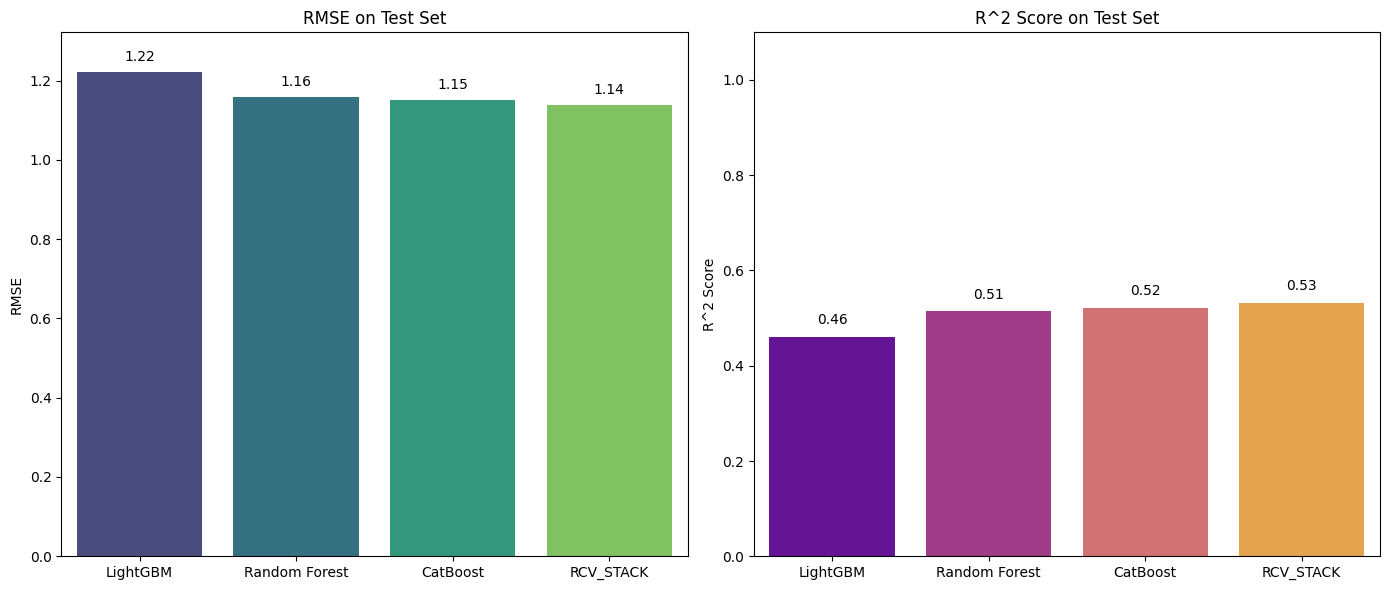

In [ ]:
# 数据整理

models = ['LightGBM', 'Random Forest', 'CatBoost','RCV_STACK']
rmse_scores = [lgb_rmse, rf_rmse, cat_rmse,rcv_stack_rmse]
r2_scores = [lgb_r2, rf_r2, cat_r2,rcv_stack_r2]

# 创建画布
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 绘制 RMSE 柱状图
sns.barplot(x=models, y=rmse_scores, ax=axes[0], palette='viridis')
axes[0].set_title('RMSE on Test Set')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_scores) + 0.1)  # 设置 y 轴范围

# 在柱子上标注数值
for i, score in enumerate(rmse_scores):
    axes[0].text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# 绘制 R^2 柱状图
sns.barplot(x=models, y=r2_scores, ax=axes[1], palette='plasma')
axes[1].set_title('R^2 Score on Test Set')
axes[1].set_ylabel('R^2 Score')
axes[1].set_ylim(0, 1.1)  # 设置 y 轴范围

# 在柱子上标注数值
for i, score in enumerate(r2_scores):
    axes[1].text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# 调整布局
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_graphviz
# 训练决策树模型
dt_regressor = DecisionTreeRegressor(
    max_depth=5,  # 控制树的最大深度（避免过深导致可视化不清晰）
    random_state=42
)
dt_regressor.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

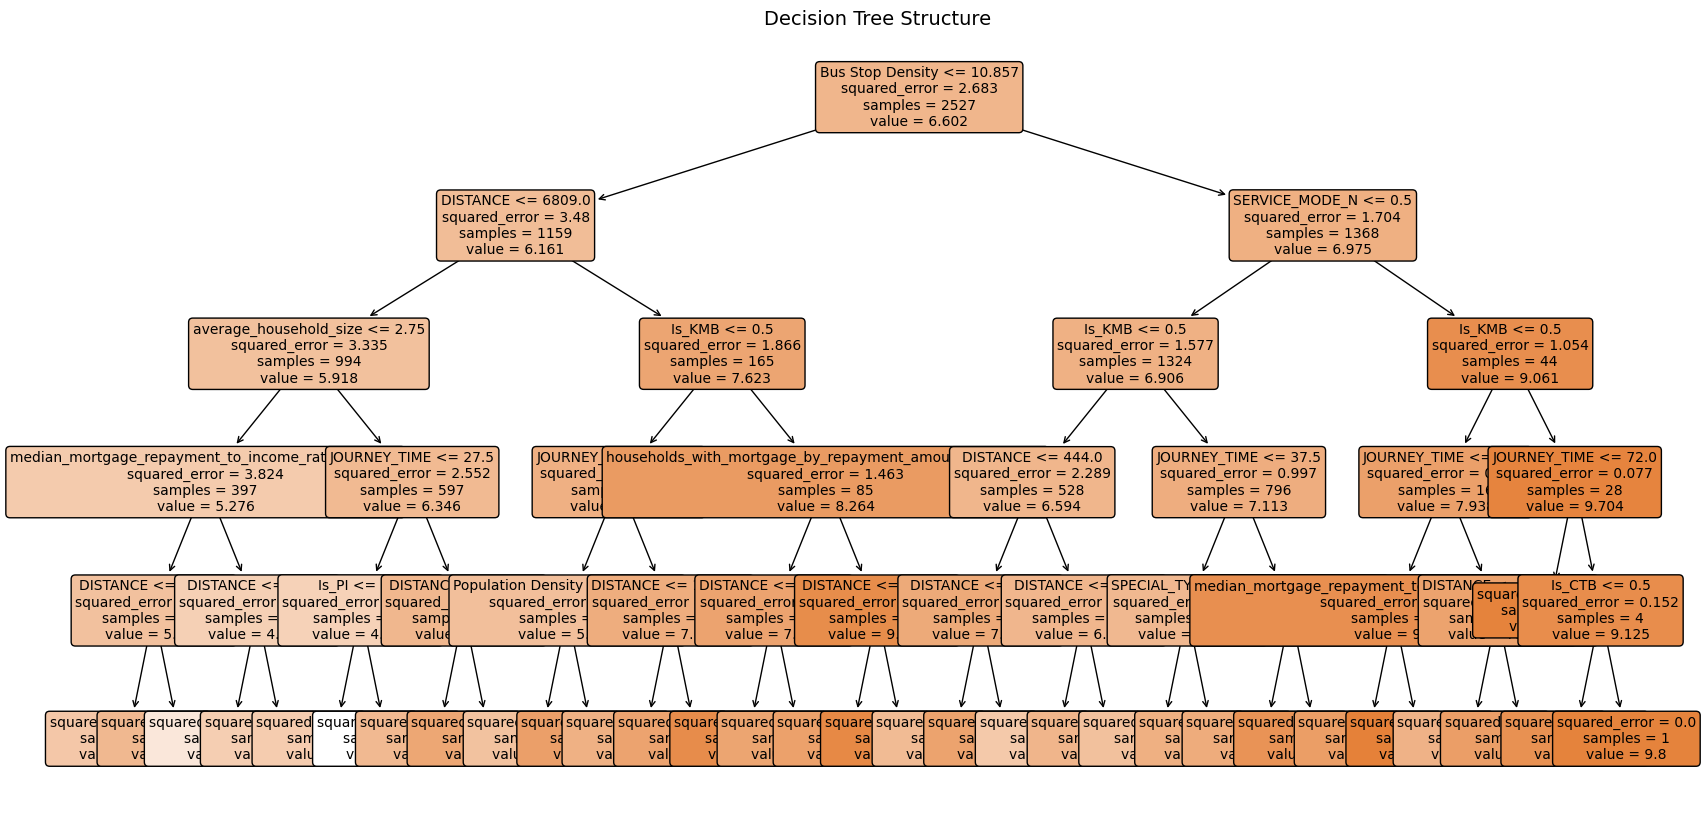

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_regressor,
    feature_names=X.columns,  # 显示特征名称
    filled=True,              # 填充颜色表示目标值
    rounded=True,             # 圆角节点
    fontsize=10
)
plt.title("Decision Tree Structure", fontsize=14)
plt.show()